In [1]:
import sys
import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group


In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
dataset = datasets.construct("imagenet-butterfly")

In [6]:
ds_train, _ = random_split(dataset.create_subset(train_split=True), [0.5, 0.5])
ds_val = dataset.create_subset(train_split=False)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|██████████| 7800/7800 [00:00<00:00, 2322394.49it/s]


We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████| 300/300 [00:00<00:00, 646936.35it/s]


In [7]:
MODEL_NAME = "imagenet-vgg16-tv"

REWRITING_LAST_LAYER = False
MAIN_LAYER = "features.23"
# MODEL_NAME = "imagenet-resnet50-tv"

In [8]:
def extract_act_penulti_feats(model_name):
    
    arr_feats = []
    arr_targets = []
    
    model = models.get_trained_model(model_name)
    utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)

    weights = model.__last_layer.weight.detach().cpu().numpy()
    
    normed_weights = weights / np.linalg.norm(weights, axis=1, keepdims=True)
    
    print(f"model_name={model_name}")
    if "vgg" in model_name:
        model.classifier[6] = torch.nn.Identity()
    elif "resnet" in model_name:
        model.fc = torch.nn.Identity()
    else:
        raise
    model.to(device)


    with torch.no_grad():
        
        for count, (x, y) in tqdm(enumerate(datasets.build_dataloader(ds_train, shuffle=False))):
            x = x.to(device)

            feat = model(x).cpu().numpy()
            arr_feats.append(feat)
            arr_targets.append(y.numpy())

    arr_feats = np.vstack(arr_feats)
    arr_targets = np.concatenate(arr_targets)
    
    return arr_feats, arr_targets, weights
            
arr_act_penulti, _, _ = extract_act_penulti_feats(MODEL_NAME)

model_name=imagenet-vgg16-tv


61it [00:24,  2.47it/s]


In [9]:
mean_act_penulti = torch.from_numpy(arr_act_penulti.mean(axis=0)).to(device)
mean_act_penulti.shape

torch.Size([4096])

In [10]:
teacher = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(teacher, dataset.selected_classes)

teacher.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [11]:
teacher_acc, _ = metrics.accuracy(
    teacher,
    dataloader=datasets.build_dataloader(ds_val, shuffle=False),
    num_classes=dataset.num_classes,
    device=device,
)
teacher_acc

0.9599999785423279

In [12]:
def make_attributor_for(
    model,
    input_statistics,
    gamma,
    epsilon,
):
    input_transform = transforms.Normalize(*input_statistics)

    low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    if isinstance(model, models.resnet.resnet.ResNet):
        canonizers = [ResNetCanonizer()]
    else:
        canonizers = []

    print(f"Instantiating EpsilonGammaBox(gamma={gamma}, eps={epsilon})")

    composite = EpsilonGammaBox(low=low, high=high, canonizers=canonizers, gamma=gamma, epsilon=epsilon)

    attributor = Gradient(model=model, composite=composite)


    return attributor

In [41]:
from copy import deepcopy

In [43]:

    
def extract_activation_context(
    model,
    layer,
    dataset,
    data_loader,
    logit_modifier,
    rng,
    gamma=0.25,
    eps=1e-6,
    device="cpu",
    number_of_selected_spatial_locations=20,
    verbose=False
):
    arr_act = []
    arr_ctx = []

    
    with make_attributor_for(model, dataset.input_statistics, gamma=gamma, epsilon=eps) as attributor:
        for batch in tqdm(data_loader):
            x, y = batch
            x = x.to(device)

            try:
                module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                    model, layer, should_retain_grad=True
                )

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad

                output_dimensions = act.shape[1:]

                # todo: check this with Gregoire again!
                ctx = torch.where(act.abs() > 0, rel / act, 0)

                assert torch.allclose(act * ctx, rel)

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

            finally:
                hook.remove()
    if verbose:
        print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx

def fh_pen(mod, inp, outp):
    
    new_outp = outp - mean_act_penulti
    
    return new_outp 
def get_act_ctx(
    model, dataset, layer, gamma=0.25, eps=1e-6, verbose=False,
    with_decomposing_penult_mean=False

):

    logit_modifier = attributors.WinningClassEvidence(num_classes=len(dataset.selected_classes))
#     logit_modifier = attributors.TargetClassEvidence(num_classes=len(dataset.selected_classes))
    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False
    )
    if with_decomposing_penult_mean:
        
        cloned_model = deepcopy(model)
        
        
        fh = cloned_model.classifier[5].register_forward_hook(fh_pen)
        
        last_layer = cloned_model.classifier[6]
        adjust_factor = last_layer.weight.data @ mean_act_penulti
        
        print("Old Bias:", last_layer.bias.data)
        new_bias = last_layer.bias.data + adjust_factor
        print("New Bias:", new_bias)
        
        last_layer.bias = torch.nn.Parameter(new_bias)
        
        
        try:
            results = extract_activation_context(
                model=cloned_model,
                layer=layer,
                dataset=dataset,
                data_loader=dl,
                logit_modifier=logit_modifier,
                rng=rng,
                device=device,
                gamma=gamma,
                eps=eps,
                verbose=verbose,
            )

        finally:
            fh.remove()
            
        return results
        
    else:
        return extract_activation_context(
            model=model,
            layer=layer,
            dataset=dataset,
            data_loader=dl,
            logit_modifier=logit_modifier,
            rng=rng,
            device=device,
            gamma=gamma,
            eps=eps,
            verbose=verbose,
        )


_arr_act, _arr_ctx = get_act_ctx(
    teacher,
    dataset,
    layer=MAIN_LAYER, 
    verbose=False,
    with_decomposing_penult_mean=True
)

Old Bias: tensor([-0.0387, -0.0239, -0.0289,  0.0019, -0.0600, -0.0135], device='cuda:0')
New Bias: tensor([18.7166, 22.5851, 15.7831, 19.3613, 20.9731, 22.1964], device='cuda:0')
Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|██████████████████████████████████████████████████████████| 61/61 [00:42<00:00,  1.45it/s]


In [44]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [45]:
dataset.selected_classes

[321, 322, 323, 324, 325, 326]

In [46]:
@torch.no_grad()
def decorrelate(A: torch.Tensor) -> torch.Tensor:
    # U_ = U @ (U.T @ U)^{-1/2}
    # ref: Hyvärinen et al. (2003), Independent Component Analysis, eq 6.37

    S = A.T @ A
    # somehow, for some classes (e.g. basketball at nfnet-f0's stage1),
    # the eigenvalue decomposition fails if using float.
    # Using double makes it more stable but slightly decreases the speed.
    # See: https://gist.github.com/p16i/4a37e10230c016fcde6c0e571c9ae010
    D, E = torch.linalg.eigh(S.double())
    D = D.float()
    E = E.float()

    inv = E @ torch.diag(1 / (torch.pow(D, 0.5))) @ E.T

    return A @ inv

In [47]:


def compute_accuracy_with_Uk(
    model, layer, Uk, dataset, dl
):
    module = utils.interceptor.get_module(model, layer)

    UUT, hook_func = fh_low_rank(Uk)
    hook = module.register_forward_hook(hook_func)

    try:
        acc, _ = metrics.accuracy(
                        model,
                        dataloader=dl,
                        num_classes=dataset.num_classes,
                        device=device,
                )
        
    finally:
        hook.remove()
        del UUT
    return acc  


In [48]:

def fh_low_rank(U):
    d, k = U.shape

    assert k <= d

    UUT = U @ U.T 
    assert UUT.shape == (d, d)

    UUT = torch.from_numpy(UUT).float().unsqueeze(2).unsqueeze(3).to(device)
    
    def do(module, inp, out):
        inp, = inp
        
        out2 = F.conv2d(out, UUT)

        if k == d and False:
            np.testing.assert_allclose(
                out.detach().cpu().numpy(), out2.detach().cpu().numpy(),
                atol=1e-3
            )

        
        return out2

    return UUT, do 

In [49]:
from collections import OrderedDict

In [50]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [51]:
from torchvision.models import VGG, ResNet

In [52]:
# def split_model_at_layer(model, layer):
#     # assert layer == "features.23"

#     if isinstance(model, VGG):
#         if "features." in layer:
        
#             index = int(layer.split(".")[1])
#             first_module = torch.nn.Sequential(OrderedDict([
#                 ("features", model.features[:index+1])
#             ]))
#             second_module = torch.nn.Sequential(OrderedDict([
#                 ("features", model.features[index+1:]),
#                 ("avgpool", model.avgpool),
#                 ("flatten", torch.nn.Flatten(start_dim=1)),
#                 ("classifier", model.classifier)
#             ]))
            
#             return first_module, second_module
#         elif "classifier." in layer:
#             index = int(layer.split(".")[1])
#             first_module = torch.nn.Sequential(OrderedDict([
#                 ("features", model.features),
#                 ("avgpool", model.avgpool),
#                 ("flatten", torch.nn.Flatten(start_dim=1)),
#                 ("classifier", model.classifier[:index+1])
#             ]))
                                               
#             second_module = torch.nn.Sequential(OrderedDict([
#                 ("classifier", model.classifier[index+1:])
#             ]))
            
#             return first_module, second_module
#     else:
#         raise

# @torch.no_grad()
# def ano():

#     model = teacher

#     for param in model.parameters():
#         param.requires_grad = False

#     for layer in [
#         "layer2", "layer3", "layer4", "fc",
#         # "features.23", "features.30", "classifier.1", "classifier.4"
#     ]:
        
#         first, second = split_model_at_layer(model, layer)
    
#         x = torch.rand(8, 3, 224, 224).to(device)
#         expected = model(x)
    
#         actual = second(first(x))

    
#         np.testing.assert_allclose(actual.cpu().numpy(), expected.cpu().numpy())
#         print(f"layer={layer}: sanity check passed!")
# ano()

In [53]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [54]:
def flatten_layers(model):
    # build all layer names

    if isinstance(model, VGG):
    
        layers = []
        for lix, layer in enumerate(model.features.children()):
            slug = f"features:{lix}"
            
            layers.append((slug, layer))
        
        layers.append(("avgpool", model.avgpool))
        layers.append(("flatten", torch.nn.Flatten(start_dim=1)))
    
        
        for lix, layer in enumerate(model.classifier.children()):
            slug = f"classifier:{lix}"
            
            layers.append((slug, layer))

    elif isinstance(model, ResNet):
        layers = [
            ("conv1", model.conv1),
            ("bn1", model.bn1),
            ("relu", model.relu),
            ("maxpool", model.maxpool),
            ("layer1", model.layer1),
            ("layer2", model.layer2),
            ("layer3", model.layer3),
            ("layer4", model.layer4),
            ("avgpool", model.avgpool),
            ("flatten", torch.nn.Flatten(start_dim=1)),
            ("fc", model.fc)
        ]
        
    
    return torch.nn.Sequential(OrderedDict(layers))

@torch.no_grad()
def sanity_check():

    new_module = flatten_layers(teacher)

    x = torch.rand(8, 3, 224, 224).to(device)
    expected = teacher(x).detach().cpu().numpy()
    actual = new_module(x).detach().cpu().numpy()

    np.testing.assert_allclose(actual, expected)
    print("sanity check: passed!")
    return new_module
sanity_check()

sanity check: passed!


Sequential(
  (features:0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:1): ReLU(inplace=True)
  (features:2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:3): ReLU(inplace=True)
  (features:4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (features:5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:6): ReLU(inplace=True)
  (features:7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:8): ReLU(inplace=True)
  (features:9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (features:10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:11): ReLU(inplace=True)
  (features:12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features:13): ReLU(inplace=True)
  (features:14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (featur

In [55]:
def get_module_names(flatten_model):
    name = list(map(lambda n: n[0], flatten_model.named_modules()))

    if isinstance(teacher, VGG):
        
        return list(filter(lambda x: x, name))
    elif isinstance(teacher, ResNet):
        return list(filter(lambda x: "." not in x and x, name))
get_module_names(flatten_layers(teacher))

['features:0',
 'features:1',
 'features:2',
 'features:3',
 'features:4',
 'features:5',
 'features:6',
 'features:7',
 'features:8',
 'features:9',
 'features:10',
 'features:11',
 'features:12',
 'features:13',
 'features:14',
 'features:15',
 'features:16',
 'features:17',
 'features:18',
 'features:19',
 'features:20',
 'features:21',
 'features:22',
 'features:23',
 'features:24',
 'features:25',
 'features:26',
 'features:27',
 'features:28',
 'features:29',
 'features:30',
 'avgpool',
 'flatten',
 'classifier:0',
 'classifier:1',
 'classifier:2',
 'classifier:3',
 'classifier:4',
 'classifier:5',
 'classifier:6']

In [56]:
# def split_model_layer_at_two_locations(model, loc1, loc2):

#     flatten_model = flatten_layers(model)

#     names = get_module_names(flatten_model)
    
#     loc1 = loc1.replace(".", ":")
#     loc2 = loc2.replace(".", ":")

#     index_loc1 = names.index(loc1)
#     index_loc2 = names.index(loc2)

#     # sanity check
#     for loc, ix in [
#         (loc1, index_loc1),
#         (loc2, index_loc2)
#     ]:

#         if isinstance(model, VGG):
            
#             expected = int(loc.split(":")[-1])
#             if "features" in loc:
#                 assert ix == expected
#                 assert flatten_model[ix] == model.features[expected]
    
#             elif "classifier" in loc:
#                 assert ix  ==  (names.index("flatten") + 1) + expected
    
#                 assert flatten_model[ix] == model.classifier[expected]
#         elif isinstance(model, ResNet):

#             # print(f"loc={loc}, ix={ix}")
#             assert flatten_model[ix] == getattr(model, loc)

    
#     return flatten_model[:index_loc1+1], \
#         flatten_model[index_loc1+1:index_loc2+1], \
#         flatten_model[index_loc2+1:] \


# @torch.no_grad()
# def ano():

#     model = teacher

#     for param in model.parameters():
#         param.requires_grad = False


#     for loc1, loc2 in [
#         ("features.23", "features.30"),
#         ("features.23", "classifier.1"),
#         ("features.23", "classifier.4"),
#         ("features.23", "classifier.6"),

#         # ("layer2", "layer3"),
#         # ("layer2", "layer4"),
#         # ("layer2", "avgpool"),
#         # ("layer2", "fc")
#     ]:

#         m1, m2, m3 = split_model_layer_at_two_locations(
#             model, 
#             loc1=loc1,
#             loc2=loc2,
#         )
        
#         x = torch.rand(8, 3, 224, 224).to(device)
#         expected = teacher(x).detach().cpu().numpy()
#         actual = m3(m2(m1(x))).detach().cpu().numpy()

#         np.testing.assert_allclose(actual, expected)

#     print("sanity check passed!")
# ano()

In [57]:
_arr_act.shape

(78000, 512)

In [58]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [59]:
# raise

In [60]:
from torch.nn.utils.parametrizations import orthogonal

In [61]:
# _arr_act_all.shape, _arr_ctx_all.shape 

In [62]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [63]:
MODEL_NAME, MAIN_LAYER

('imagenet-vgg16-tv', 'features.23')

In [64]:
CACHE_STORE = dict()

def get_act_ctx_for_basis(decomposing_penact_mean):
    
    if decomposing_penact_mean in CACHE_STORE:
        print(f"decomposing_penact_mean={decomposing_penact_mean}: get from cache")
        return CACHE_STORE[decomposing_penact_mean]
    
    CACHE_STORE[decomposing_penact_mean] = get_act_ctx(
        teacher,
        dataset,
        layer=MAIN_LAYER, 
        verbose=False,
        with_decomposing_penult_mean=decomposing_penact_mean
    )

    return CACHE_STORE[decomposing_penact_mean]

get_act_ctx_for_basis(False)

Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|██████████████████████████████████████████████████████████| 61/61 [00:42<00:00,  1.44it/s]


(array([[ 5.8492975,  0.       ,  2.0312076, ...,  1.6946551,  0.       ,
          2.0202634],
        [ 9.722342 ,  0.       , 10.938011 , ...,  8.591161 ,  0.       ,
          0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          0.       ],
        ...,
        [ 0.       ,  0.       ,  0.       , ...,  9.9440775,  0.       ,
          6.7946773],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          7.482664 ]], dtype=float32),
 array([[ 1.0213935e-03,  0.0000000e+00,  9.4265316e-04, ...,
          6.0104555e-04,  0.0000000e+00, -5.9793310e-05],
        [ 8.5590596e-05,  0.0000000e+00, -2.0719480e-04, ...,
         -1.1064559e-04,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [ 0.0000000e+

In [65]:
get_act_ctx_for_basis(True)

Old Bias: tensor([-0.0387, -0.0239, -0.0289,  0.0019, -0.0600, -0.0135], device='cuda:0')
New Bias: tensor([18.7166, 22.5851, 15.7831, 19.3613, 20.9731, 22.1964], device='cuda:0')
Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|██████████████████████████████████████████████████████████| 61/61 [00:42<00:00,  1.44it/s]


(array([[ 5.8492975,  0.       ,  2.0312076, ...,  1.6946551,  0.       ,
          2.0202634],
        [ 9.722342 ,  0.       , 10.938011 , ...,  8.591161 ,  0.       ,
          0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          0.       ],
        ...,
        [ 0.       ,  0.       ,  0.       , ...,  9.9440775,  0.       ,
          6.7946773],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          0.       ],
        [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
          7.482664 ]], dtype=float32),
 array([[ 4.5603604e-04,  0.0000000e+00,  1.3305568e-03, ...,
         -1.7041116e-03,  0.0000000e+00,  4.0848929e-05],
        [ 2.1934688e-04,  0.0000000e+00,  8.5606991e-04, ...,
          1.9396331e-04,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [ 0.0000000e+

['pca', 'prcasortabs', 'prcasortabs:decommean']


  0%|                                                                    | 0/6 [00:00<?, ?it/s]

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs:decommean; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=True: get from cache


 17%|██████████                                                  | 1/6 [00:08<00:41,  8.36s/it]

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs:decommean; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=True: get from cache


...

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs:decommean; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=True: get from cache


 83%|██████████████████████████████████████████████████          | 5/6 [00:40<00:08,  8.06s/it]

basis_name=pca; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=False: get from cache
basis_name=prcasortabs:decommean; layer=features.23; model_name=imagenet-vgg16-tv
decomposing_penact_mean=True: get from cache


100%|████████████████████████████████████████████████████████████| 6/6 [00:49<00:00,  8.20s/it]


,layer,k,basis_name,acc_val
0,features.23,1,pca,0.183333
1,features.23,1,prcasortabs,0.166667
2,features.23,1,prcasortabs:decommean,0.166667
3,features.23,2,pca,0.106667
4,features.23,2,prcasortabs,0.210000
5,features.23,2,prcasortabs:decommean,0.180000
6,features.23,4,pca,0.400000
7,features.23,4,prcasortabs,0.400000
8,features.23,4,prcasortabs:decommean,0.360000
9,features.23,8,pca,0.746667


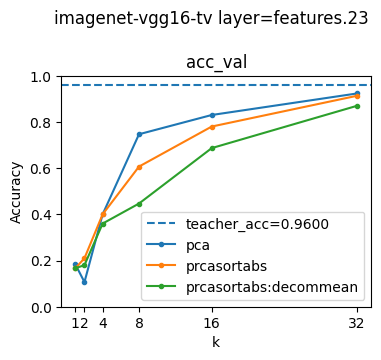

In [66]:
import matplotlib as mpl


def compute_accuracy_of_basis_at_k(
    model, dataset, layer, 
    arr_ks,
    arr_bases,
):
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)
    dl_train = datasets.build_dataloader(ds_train, shuffle=False)    
    
    rows = []
    print(arr_bases)
    for k in tqdm(arr_ks):
        for basis_name in arr_bases:
            Uk = estimate_basis(
                layer=layer,
                basis_name=basis_name, 
                k=k
            )
            acc_val = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_val)
#             acc_train = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_train)

            rows.append(
                    dict(
                        layer=layer, k=k, 
                        basis_name=basis_name,
                        acc_val=acc_val,
#                         acc_train=acc_train
                    )
            )
    

    df = pd.DataFrame(rows)

    return df



def estimate_basis(layer, basis_name, k):
    print(f"basis_name={basis_name}; layer={MAIN_LAYER}; model_name={MODEL_NAME}")
    if basis_name == "pca":
        arr_act, _ = get_act_ctx_for_basis(decomposing_penact_mean=False)
        _, pca_eigvecs = np.linalg.eigh(arr_act.T @ arr_act)
        U = np.flip(pca_eigvecs, axis=1).copy()
        return U[:, :k].copy()

    elif basis_name == "prcasortabs":
        arr_act, arr_ctx = get_act_ctx_for_basis(decomposing_penact_mean=False)

        ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        eigvals, eigvecs = np.linalg.eigh(ccov)

        assert eigvals.shape == (arr_act.shape[1], )
    
        indices = np.argsort(-np.abs(eigvals))

        U = np.copy(eigvecs[:, indices])
        return U[:, :k].copy()
    
    elif basis_name == "prcasortabs:decommean":

        arr_act, arr_ctx = get_act_ctx_for_basis(decomposing_penact_mean=True)

        ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

        eigvals, eigvecs = np.linalg.eigh(ccov)

        assert eigvals.shape == (arr_act.shape[1], )
    
        indices = np.argsort(-np.abs(eigvals))

        U = np.copy(eigvecs[:, indices])
        return U[:, :k].copy()

    else:
        raise NotImplementedError(f"basis_name={basis_name}")

def estimate_rank_k_accuracies(
    model, dataset, layer,
    arr_bases=[
        "pca",
        "prcasortabs", 
        "prcasortabs:decommean",
    ],
    arr_ks=[1,2, 4, 8, 16, 32],
):

    colors = mpl.cm.Blues
    nbases = len(arr_bases)

    df = compute_accuracy_of_basis_at_k(
        model, dataset, layer, 
        arr_bases=arr_bases,
        arr_ks=arr_ks
    )

    torch.cuda.empty_cache()

    def alias(name):
        return name
        if name == "pca":
            return "PCA"
        elif "prcaopt:" in name:
            _, slug = name.split(":")
            return f"PCA-LH:{slug}"
        else:
            raise
            
    def ls(name):
        if name == "prcasortabs-penu":
            return "--"
        else:
            return "-"

    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prcaopt":
            return "red"
        else:
            return None
            

    cols = [
#         "acc_train", 
        "acc_val"
    ]
    ncols = len(cols)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(f"{MODEL_NAME} layer={layer}", y=1.1)

    for cix, col in enumerate(cols):
        plt.subplot(1, ncols, cix+1)
        plt.title(col)
        plt.axhline(teacher_acc, ls="--", label=f"teacher_acc={teacher_acc:.4f}")
        for nix, name in enumerate(df.basis_name.unique()):
            _df = df[df.basis_name == name]
            
            plt.plot(
                _df.k, 
                _df[col],
                label=alias(name),
                ls=ls(name),
                marker=".",
#                 color=color(name) if name in ["pca", "prcaopt"] else colors((nix+0.1)/nbases) 
            )
    
        plt.ylim([0, 1])
        plt.legend()
        plt.ylabel("Accuracy"); plt.xlabel("k")
        plt.xticks(df.k.unique())
    
    return df
    
estimate_rank_k_accuracies(model=teacher, dataset=dataset, layer=MAIN_LAYER)